## **Importação de Bibliotecas**

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
from matplotlib.ticker import AutoMinorLocator
import seaborn as sns
from glob import glob
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

plt.rcParams.update({
    "font.family": "serif",
    "mathtext.fontset": "cm",
    "font.size": 12 
})

In [7]:
# path = r"Y:\proc\pimega_450d\2025\february\agua_083Kelvin_066"

## **Analisando os dados**

### **DATA**

In [8]:
path_data = r"C:\Users\arthur25004\OneDrive - ILUM ESCOLA DE CIÊNCIA\Documentos\3° Semestre\IP_II\demo_dados\data\main_folder_vs55\vs55"
files_data_data = []

for path_arquivo_hdf5 in glob(f"{path_data}/*.hdf5"):
    nome = path_arquivo_hdf5.split("\\")[-1].replace(".hdf5", "")
    temp = nome.split("_")[2].replace("Kelvin", "") if "RAMP" in nome else nome.split("_")[1].replace("Kelvin", "")
    step = int(nome.split("_")[-1])

    files_data_data.append([nome, temp, step])

files_data_data.sort(key=lambda x: int(x[2]))

print("Temperatura:", end=" ")
for data in files_data_data: print(f"{data[1]}", end=" | ")
print("\nStep:", end=" "*8)
for data in files_data_data: print(f"{data[2]}", end=" | ")

print(f"\nN Dados: {len(files_data_data)}")


Temperatura: 296 | 296 | 285 | 285 | 279 | 279 | 272 | 272 | 263 | 263 | 254 | 254 | 244 | 244 | 234 | 234 | 224 | 224 | 212 | 212 | 200 | 200 | 188 | 188 | 176 | 176 | 166 | 166 | 156 | 156 | 146 | 146 | 137 | 137 | 129 | 129 | 121 | 121 | 114 | 114 | 107 | 107 | 102 | 102 | 096 | 096 | 092 | 092 | 088 | 088 | 084 | 084 | 081 | 081 | 080 | 080 | 081 | 081 | 082 | 082 | 086 | 086 | 093 | 093 | 100 | 100 | 106 | 106 | 112 | 112 | 118 | 118 | 125 | 125 | 131 | 131 | 138 | 138 | 144 | 144 | 150 | 150 | 156 | 156 | 163 | 163 | 169 | 169 | 175 | 175 | 182 | 182 | 188 | 188 | 194 | 194 | 200 | 200 | 207 | 207 | 213 | 213 | 219 | 219 | 226 | 226 | 232 | 232 | 238 | 238 | 245 | 245 | 251 | 251 | 257 | 257 | 264 | 264 | 270 | 270 | 276 | 276 | 283 | 283 | 289 | 289 | 295 | 295 | 300 | 300 | 
Step:        128 | 129 | 130 | 131 | 132 | 133 | 134 | 135 | 136 | 137 | 138 | 139 | 140 | 141 | 142 | 143 | 144 | 145 | 146 | 147 | 148 | 149 | 150 | 151 | 152 | 153 | 154 | 155 | 156 | 157 | 158 | 159 | 1

Algo observado que me parece meio esquisito é que os valores de temperatura só mudam após dois passos. Pensado aqui, talvez o PIMEGA da Paineira faça a medição de dois steps com intervalos muito próximos, de forma a não dar tempo da temperatura mudar.

Será que esses passos representam uma mudança de angulação ou seria algo mais como uma duplicata?

In [9]:
houve_diferente = False
for i in range(len(files_data_data)):
    if i % 2 == 1:
        if files_data_data[i][1] != files_data_data[i-1][1]:
            houve_diferente = True
            print("diferente")

if houve_diferente:
     print("Algum par foi diferente")
else: 
     print("Nenhum par foi diferente")

Nenhum par foi diferente


### **PROC**

In [10]:
path_proc = r"C:\Users\arthur25004\OneDrive - ILUM ESCOLA DE CIÊNCIA\Documentos\3° Semestre\IP_II\demo_dados\proc\proc\main_folder_vs55\merge_files"
files_data_proc = []

for path_arquivo_csv in glob(f"{path_proc}/*.csv"):
    df = pd.read_csv(path_arquivo_csv)
    nome = path_arquivo_csv.split("\\")[-1].replace(".csv", "")
    temp = nome.split("_")[2].replace("Kelvin", "")
    step = int(nome.split("_")[-2])

    files_data_proc.append([nome, temp, step, df])    

files_data_proc.sort(key=lambda x: int(x[2]))

print("Temperatura:", end=" ")
for data in files_data_proc: print(data[1], end=" | ")
print("\nStep:", end=" "*8)
for data in files_data_proc: print(data[2], end=" | ")

print(f"\nN dados: {len(files_data_proc)}")


Temperatura: 296 | 285 | 279 | 272 | 263 | 254 | 244 | 234 | 224 | 212 | 200 | 188 | 176 | 166 | 156 | 146 | 137 | 129 | 121 | 114 | 107 | 102 | 096 | 092 | 088 | 084 | 081 | 182 | 184 | 082 | 086 | 093 | 100 | 106 | 112 | 118 | 125 | 131 | 138 | 144 | 150 | 156 | 163 | 169 | 175 | 182 | 188 | 194 | 200 | 207 | 213 | 219 | 226 | 232 | 238 | 245 | 251 | 257 | 264 | 270 | 276 | 283 | 289 | 295 | 256 | 
Step:        128 | 130 | 132 | 134 | 136 | 138 | 140 | 142 | 144 | 146 | 148 | 150 | 152 | 154 | 156 | 158 | 160 | 162 | 164 | 166 | 168 | 170 | 172 | 174 | 176 | 178 | 180 | 182 | 184 | 186 | 188 | 190 | 192 | 194 | 196 | 198 | 200 | 202 | 204 | 206 | 208 | 210 | 212 | 214 | 216 | 218 | 220 | 222 | 224 | 226 | 228 | 230 | 232 | 234 | 236 | 238 | 240 | 242 | 244 | 246 | 248 | 250 | 252 | 254 | 256 | 
N dados: 65


### **Ajustando os valores de Temperatura**

Os arquivos *``data``* são os que contém os valores de temperatura correta para cada step do *``proc``*. Como os arquivos de dados do *``proc``* foram juntados ("MERGE"), no *``data``* será feita a média dos valores de temperatura de dois em dois. 

O valor médio resultante irá substituir o valor de temperatura em *``proc``* naquele step.

<!-- | Dado | Forma de Medição |
| :--- | ---: | 
| DATA | ?Não sei? |
| PROC | Pistola  | -->



In [11]:
data_corrigido = []
for i in range(len(files_data_data)):
    if i % 2 == 1:
        media = (int(files_data_data[i][1]) + int(files_data_data[i-1][1])) / 2
        data_corrigido.append((media, files_data_data[i-1][2]))

print("Temperatura:", end=" ")
for data in data_corrigido: print(data[0], end=" | ")
print("\nStep:", end=" "*8)
for data in data_corrigido: print(data[1], end=" | ")

Temperatura: 296.0 | 285.0 | 279.0 | 272.0 | 263.0 | 254.0 | 244.0 | 234.0 | 224.0 | 212.0 | 200.0 | 188.0 | 176.0 | 166.0 | 156.0 | 146.0 | 137.0 | 129.0 | 121.0 | 114.0 | 107.0 | 102.0 | 96.0 | 92.0 | 88.0 | 84.0 | 81.0 | 80.0 | 81.0 | 82.0 | 86.0 | 93.0 | 100.0 | 106.0 | 112.0 | 118.0 | 125.0 | 131.0 | 138.0 | 144.0 | 150.0 | 156.0 | 163.0 | 169.0 | 175.0 | 182.0 | 188.0 | 194.0 | 200.0 | 207.0 | 213.0 | 219.0 | 226.0 | 232.0 | 238.0 | 245.0 | 251.0 | 257.0 | 264.0 | 270.0 | 276.0 | 283.0 | 289.0 | 295.0 | 300.0 | 
Step:        128 | 130 | 132 | 134 | 136 | 138 | 140 | 142 | 144 | 146 | 148 | 150 | 152 | 154 | 156 | 158 | 160 | 162 | 164 | 166 | 168 | 170 | 172 | 174 | 176 | 178 | 180 | 182 | 184 | 186 | 188 | 190 | 192 | 194 | 196 | 198 | 200 | 202 | 204 | 206 | 208 | 210 | 212 | 214 | 216 | 218 | 220 | 222 | 224 | 226 | 228 | 230 | 232 | 234 | 236 | 238 | 240 | 242 | 244 | 246 | 248 | 250 | 252 | 254 | 256 | 

#### **Verificando se houve mudanças**

Será os valores medidos de temperação realmente mudaram a depender da forma de medição?

In [12]:
diffs = []
for i, (data_proc, data_corr) in enumerate(zip(files_data_proc, data_corrigido)):
    temp_proc = float(data_proc[1])
    temp_corr = data_corr[0]

    if temp_proc != temp_corr:
        diffs.append((i, f"temp_proc: {temp_proc}", f"temp_corr: {temp_corr}"))

n_mudancas = len(diffs)

print(f"O número de mundanças foi: {n_mudancas}")

if n_mudancas != 0:
    print("\n--- Alterações ---")
    for i in range(min(5, n_mudancas)):
        print(diffs[i][1:3])


O número de mundanças foi: 3

--- Alterações ---
('temp_proc: 182.0', 'temp_corr: 80.0')
('temp_proc: 184.0', 'temp_corr: 81.0')
('temp_proc: 256.0', 'temp_corr: 300.0')


#### **Aplicando as mudanças**

In [13]:
files_data_proc_corr = files_data_proc

for i, (data_proc, data_corr) in enumerate(zip(files_data_proc, data_corrigido)):
    step_proc = data_proc[2]
    step_data = data_corr[1]

    if step_proc != step_data:
        print(f"Houve uma diferença entre os steps em {i} | step_proc = {step_proc}, step_data = {step_data}")
        continue
        
    temp_corr = data_corr[0]
    files_data_proc_corr[i][1] = temp_corr


print("Temperatura:", end=" ")
for data in files_data_proc_corr: print(data[1], end=" | ")
print("\nStep:", end=" "*8)
for data in files_data_proc_corr: print(data[2], end=" | ")


Temperatura: 296.0 | 285.0 | 279.0 | 272.0 | 263.0 | 254.0 | 244.0 | 234.0 | 224.0 | 212.0 | 200.0 | 188.0 | 176.0 | 166.0 | 156.0 | 146.0 | 137.0 | 129.0 | 121.0 | 114.0 | 107.0 | 102.0 | 96.0 | 92.0 | 88.0 | 84.0 | 81.0 | 80.0 | 81.0 | 82.0 | 86.0 | 93.0 | 100.0 | 106.0 | 112.0 | 118.0 | 125.0 | 131.0 | 138.0 | 144.0 | 150.0 | 156.0 | 163.0 | 169.0 | 175.0 | 182.0 | 188.0 | 194.0 | 200.0 | 207.0 | 213.0 | 219.0 | 226.0 | 232.0 | 238.0 | 245.0 | 251.0 | 257.0 | 264.0 | 270.0 | 276.0 | 283.0 | 289.0 | 295.0 | 300.0 | 
Step:        128 | 130 | 132 | 134 | 136 | 138 | 140 | 142 | 144 | 146 | 148 | 150 | 152 | 154 | 156 | 158 | 160 | 162 | 164 | 166 | 168 | 170 | 172 | 174 | 176 | 178 | 180 | 182 | 184 | 186 | 188 | 190 | 192 | 194 | 196 | 198 | 200 | 202 | 204 | 206 | 208 | 210 | 212 | 214 | 216 | 218 | 220 | 222 | 224 | 226 | 228 | 230 | 232 | 234 | 236 | 238 | 240 | 242 | 244 | 246 | 248 | 250 | 252 | 254 | 256 | 

## **Plotando os dados**

Eu deveria plotar os valores no eixo *y* à esquerda? Eles não possuem mais um significado eu acho.

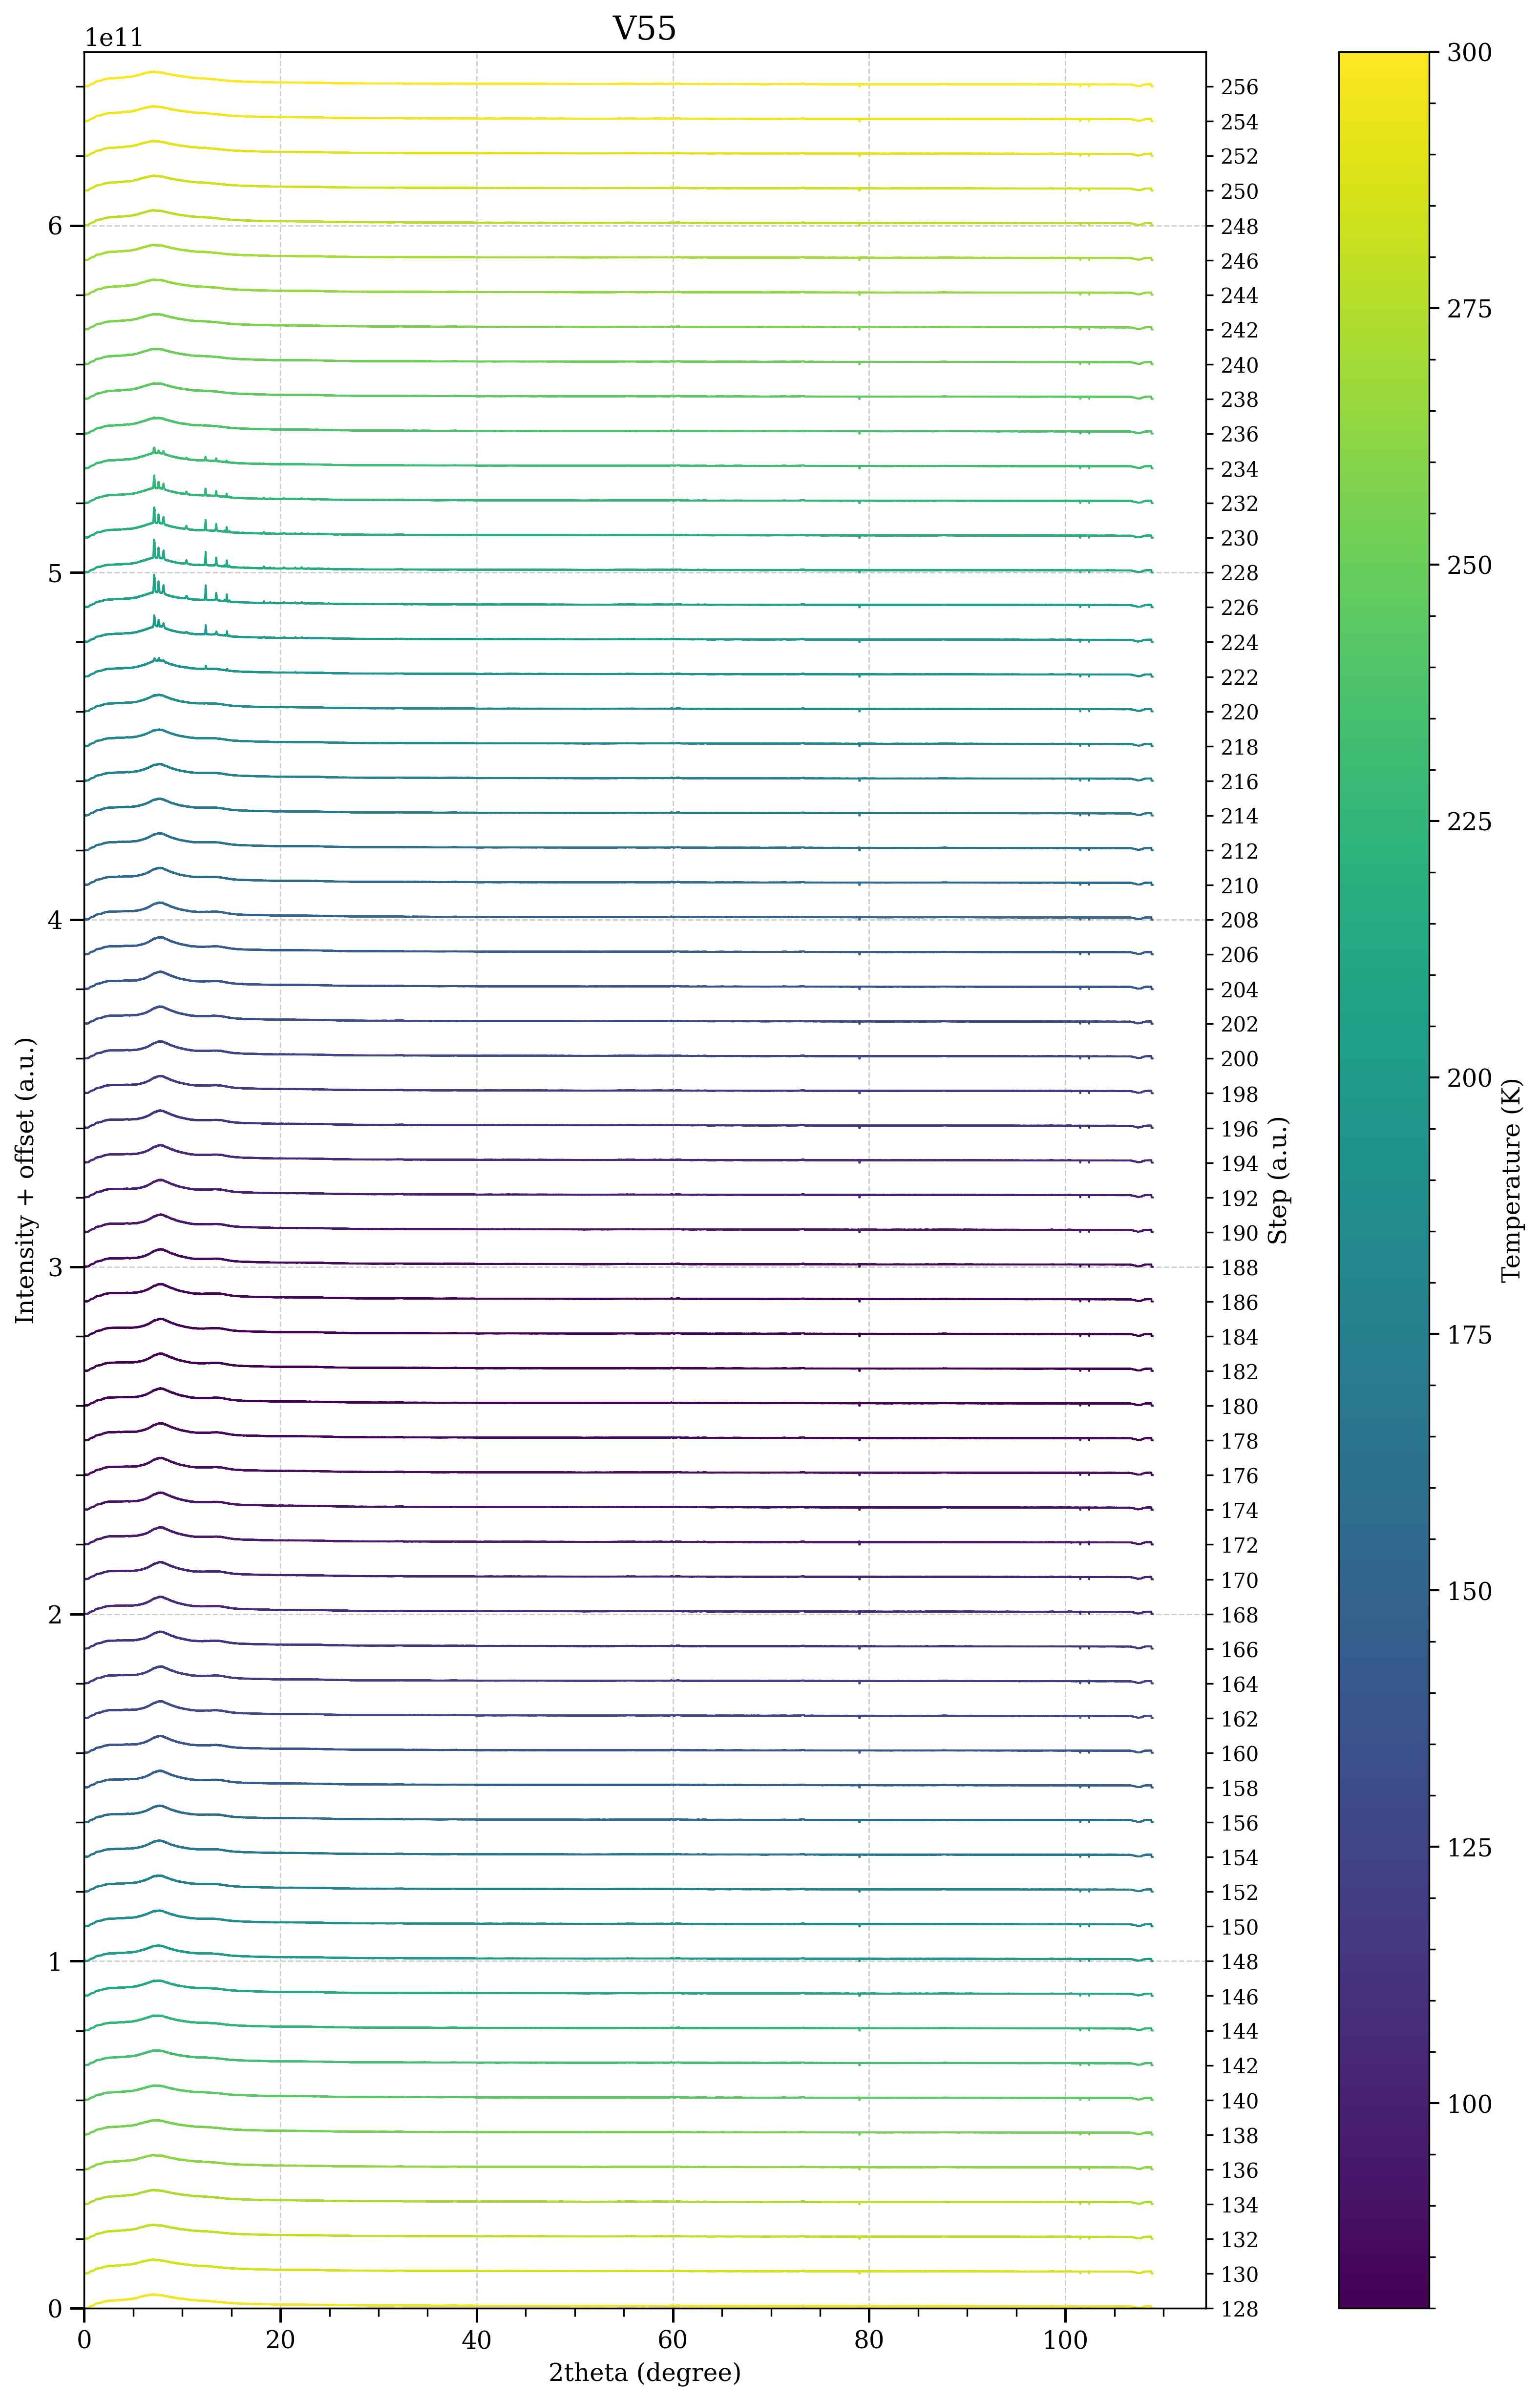

In [14]:
temperaturas = [data[1] for data in files_data_proc_corr]
temp_min = min(temperaturas)
temp_max = max(temperaturas)

norm = mcolors.Normalize(vmin=temp_min, vmax=temp_max)
cmap = plt.colormaps.get_cmap("viridis")

offset = 0
offset_step = 1e10

fig = plt.figure(figsize=(13, 20), dpi=300)
ax1 = fig.add_subplot(1, 1, 1)

posicoes_y = []
labels_step = []

for data in files_data_proc_corr:
    nome = data[0]
    temp = data[1]
    step = data[2]
    df = data[3]

    X = df["2theta (degree)"]
    y = df["Intensity"]

    cor = cmap(norm(temp))
    ax1.plot(X, y+offset, linewidth=0.9, color=cor)

    posicoes_y.append(offset)
    labels_step.append(step)

    offset += offset_step

plt.title("V55", fontsize=16)
ax1.set_xlabel("2theta (degree)")
ax1.set_ylabel("Intensity + offset (a.u.)")
ax1.set_xlim(0)
ax1.set_ylim(bottom=0, top=offset)

# ax1.set_yticks([]) 
ax1.xaxis.set_minor_locator(AutoMinorLocator())
ax1.yaxis.set_minor_locator(AutoMinorLocator())
ax1.tick_params(which="major", direction="out", length=7, width=1.2)
ax1.tick_params(which="minor", direction="out", length=4, width=0.8)
ax1.grid(which="major", linestyle="--", linewidth=0.7, alpha=0.6)

# eixo y à direita
ax2 = ax1.twinx()
ax2.set_ylim(ax1.get_ylim())
ax2.set_yticks(posicoes_y)
ax2.set_yticklabels(labels_step, fontsize=10)
ax2.set_ylabel("Step (a.u.)")

# Colorbar
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
cbar = fig.colorbar(sm, ax=ax1, pad=0.09, aspect=25)
cbar.set_label("Temperature (K)")

cbar.ax.yaxis.set_minor_locator(AutoMinorLocator())
cbar.ax.tick_params(which="major", direction="out", length=5, width=1)
cbar.ax.tick_params(which="minor", direction="out", length=3, width=0.8)
    
plt.show()
    

### **Plotando uma matriz de correlação**

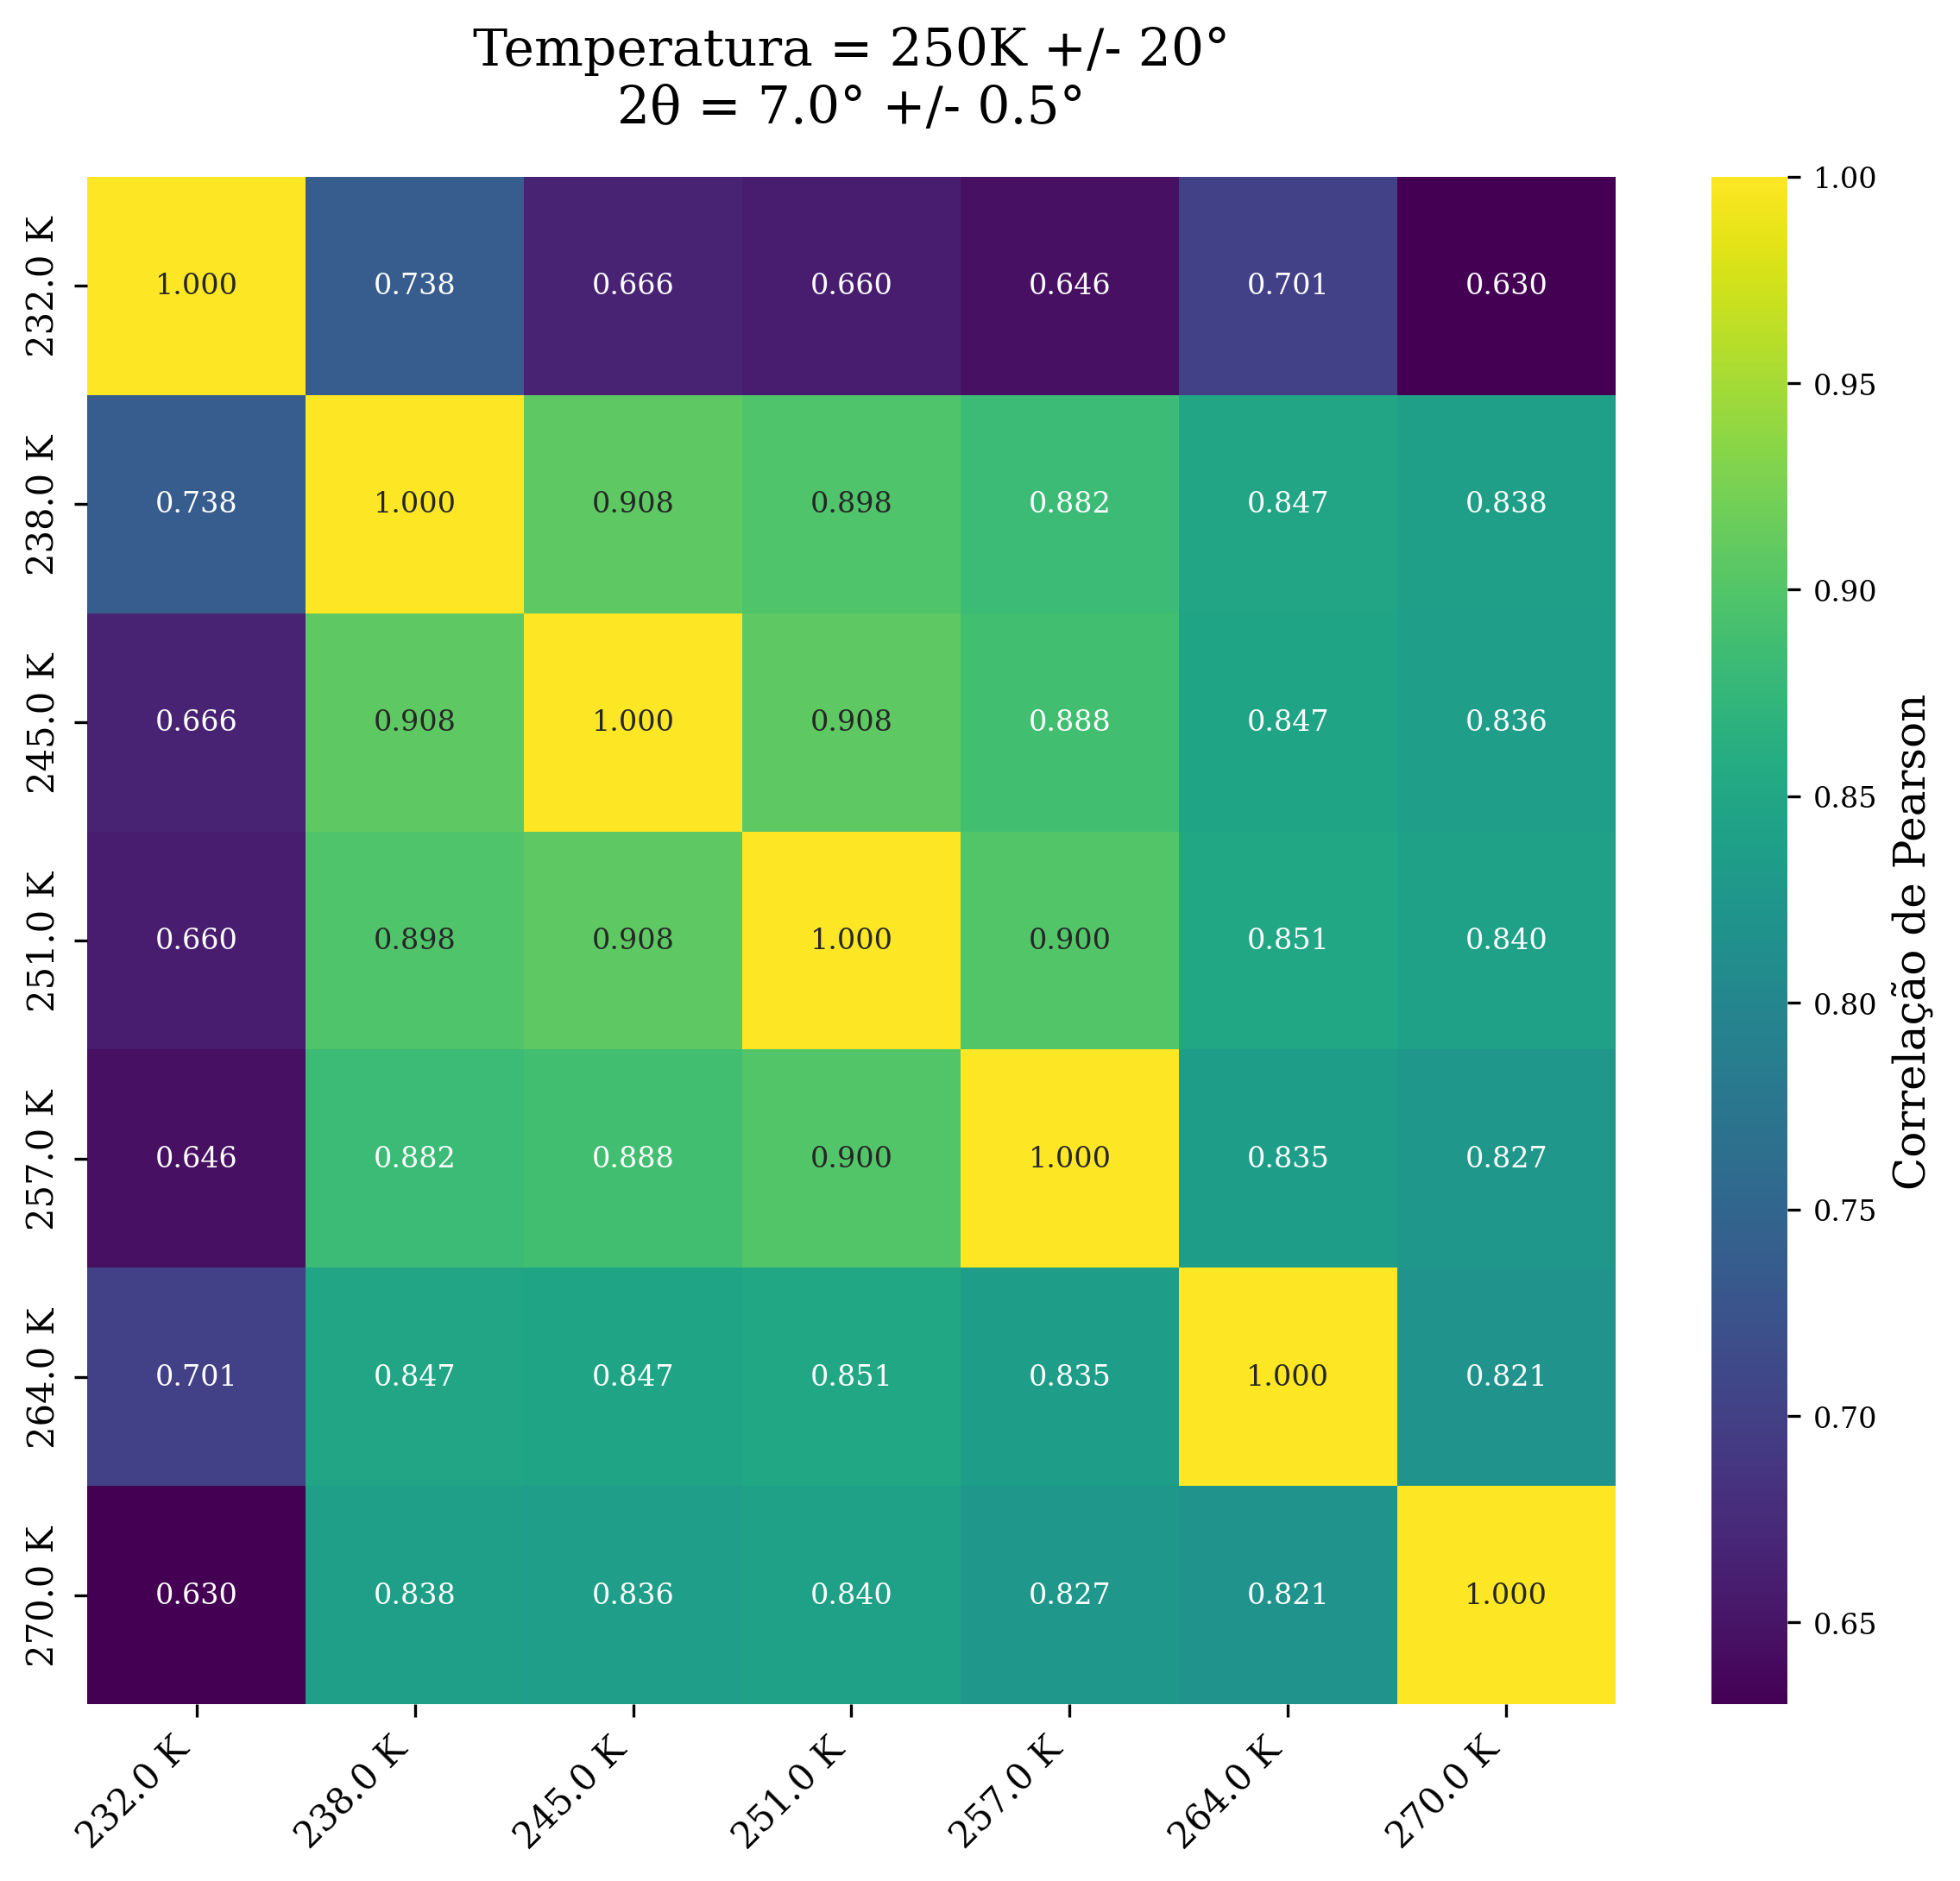

In [43]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


target_temp = 250
tol_temp = 20 

target_2theta = 7.0
tol_2theta = 0.5  

dados_filtrados = {}

for data in files_data_proc_corr:
    nome = data[0]
    temp = data[1]
    step = data[2]
    df = data[3]
    
    if (target_temp - tol_temp) <= temp <= (target_temp + tol_temp) and step >= 200:
        
        df_filtro = df[(df["2theta (degree)"] >= target_2theta - tol_2theta) & 
                       (df["2theta (degree)"] <= target_2theta + tol_2theta)]
        
        dados_filtrados[f"{temp} K"] = df_filtro["Intensity"].values


# Cria um DataFrame onde as colunas são as Temperaturas e as linhas os pontos do difratograma
df_matrix = pd.DataFrame(dados_filtrados)
corr_matrix = df_matrix.corr(method="pearson")

fig, ax = plt.subplots(figsize=(8, 7), dpi=300)

heatmap = sns.heatmap(
    corr_matrix, 
    ax=ax, 
    cmap="viridis",      
    annot=True,   
    fmt=".3f",        
    annot_kws={"size": 8}, 
    square=True,         
    cbar_kws={"label": "Correlação de Pearson"},
)

cbar = heatmap.collections[0].colorbar
cbar.ax.tick_params(labelsize=8)
ax.set_title(f"Temperatura = {target_temp}K +/- {tol_temp}°\n2θ = {target_2theta}° +/- {tol_2theta}°", pad=15)

plt.xticks(rotation=45, ha="right", fontsize=10) 
plt.yticks(fontsize=10)
plt.tight_layout()

plt.show()

## **Código de Exemplo**

In [ ]:
# file_data = []

# sns.color_palette("rocket", as_cmap=True)

# # Carrega e processa todos os arquivos CSV na pasta "dados"
# for diretorio_csv in glob(f"{path}/*.csv"):
#     nome = diretorio_csv.split("\\")[-1].replace(".csv", "")
#     nome_txt = nome.split(" ")[0]  # Nome a ser utilizado no arquivo final

#     data = pd.read_csv(diretorio_csv)
#     data.columns = ["2theta (º)", nome]
#     max_value = data[nome].max()
#     file_data.append((nome, data, max_value))

# # Ordena os dados em ordem crescente
# file_data.sort(key=lambda x: x[2])

# # Cria DataFrame para a matriz de correlação
# heat = pd.DataFrame()
# for nome, data, _ in file_data:
#     if heat.empty:
#         heat = data.set_index("2theta (º)")
#     else:
#         heat[nome] = data[nome].values

# # Cria a matriz de correlação Pearson
# corr_pearson = heat.corr(method="pearson")

# # Cria uma figura
# fig, ax = plt.subplots(figsize=(14, 6))

# # Offset inicial e incremento
# offset = 0
# incremento_offset = 1e10

# # Adicionar curvas ao gráfico
# for nome, data, _ in file_data:
#     data[nome] += offset
#     ax.plot(data["2theta (º)"], data[nome], label=nome, linewidth=0.8)
#     offset += incremento_offset

# # Configurações principais
# ax.set_title("Difração")
# ax.set_xlim(0, 40)
# ax.set_ylim(0, 1.1e11)
# ax.set_xlabel("2theta (º)")
# ax.set_ylabel("Intensidade (u.a.)")
# ax.legend(loc="upper left", bbox_to_anchor=(0.02, 0.98), frameon=True)

# # Criar gráfico insetado no canto superior direito
# ax_inset = inset_axes(ax, width="50%", height="50%", loc="upper right", borderpad=0 # Ajustar o espaçamento para ficar mais rente
# )

# # Plota o heatmap no gráfico de difração
# sns.heatmap(
#     corr_pearson,
#     ax=ax_inset,
#     cmap="viridis",
#     cbar=False,  
#     annot=True,
#     fmt=".3",
#     annot_kws={"size": 10},  
#     square=True,  # Força o formato quadrado
# )

# # Configura título e ajusta os labels para o gráfico inserido
# ax_inset.set_title("Correlação Pearson", fontsize=10)
# ax_inset.set_xticklabels(ax_inset.get_xticklabels(), rotation=30, fontsize=8)
# ax_inset.set_yticklabels(ax_inset.get_yticklabels(), fontsize=8)

# # Salvar como SVG
# plt.savefig(f"Plots/completos/Difração - {nome_txt}.svg")

# # Exibir o gráfico
# #plt.show()

